In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Import Libraries

In [2]:
pip install -q transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 27.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [3]:
import pandas as pd
import numpy as np

from transformers import AutoTokenizer, AutoModelForMultipleChoice,TrainingArguments, Trainer, EarlyStoppingCallback
from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

import torch

In [4]:
import wandb
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")

wandb.login(key=wandb_api_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# EDA

In [6]:
train_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

print(train_df.shape)
print(test_df.shape)

(2000, 8)
(500, 7)


In [7]:
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


### Missing Value Check

In [8]:
train_df.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

### Viz1: Plot count of each correct answer choice


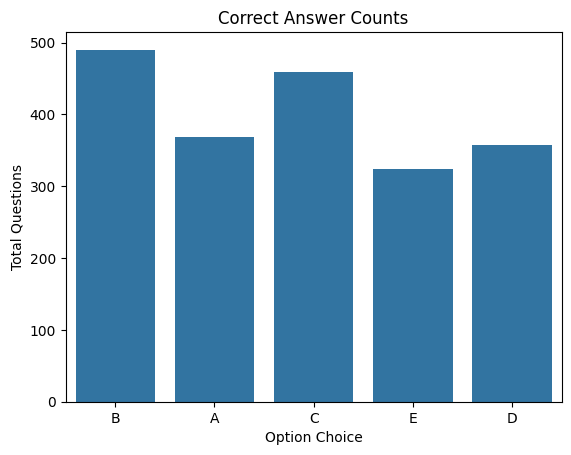

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="answer", data=train_df)
plt.title("Correct Answer Counts")
plt.xlabel("Option Choice")
plt.ylabel("Total Questions")
plt.show()


### Viz2: Word count distribution

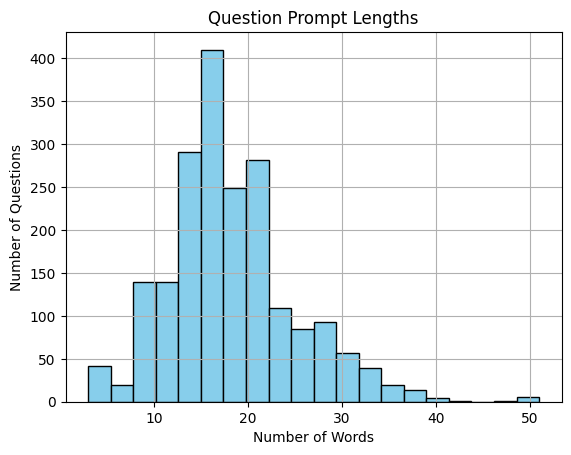

Average prompt length: 18.1465
Max prompt length    : 51


In [10]:
train_viz = train_df.copy()

train_viz["prompt_words"] = train_viz["prompt"].str.split().str.len()

train_viz["prompt_words"].hist(bins=20, color="skyblue", edgecolor="black")
plt.title("Question Prompt Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Questions")
plt.show()

print("Average prompt length:", train_viz["prompt_words"].mean())
print("Max prompt length    :", train_viz["prompt_words"].max())

# Train-Test Split

In [11]:
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df["answer"], random_state=4524)

# Evaluation Metric

## MAP@3
Score = 1.0 if correct answer is rank 1, 0.5 if rank 2, 1/3 if rank 3, else 0.

In [12]:
def mean_average_precision_at_3(true_labels, top3_preds):
    scores = []
    for true_label, preds in zip(true_labels, top3_preds):
        if true_label == preds[0]:
            scores.append(1.0)
        elif true_label == preds[1]:
            scores.append(0.5)
        elif true_label == preds[2]:
            scores.append(1 / 3)
        else:
            scores.append(0.0)
    return np.mean(scores)

# Model 2: DeBERTA Fine Tune'

In [13]:
run = wandb.init(
    project="24f3004524-t22026",
    name="deberta-run1"
)

wandb: setting up run 3kuxnpdo
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260730_202842-3kuxnpdo
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run deberta-run1
wandb: ⭐️ View project at https://wandb.ai/pranay12aggarwal-indian-institute-of-technology-madras/24f3004524-t22026
wandb: 🚀 View run at https://wandb.ai/pranay12aggarwal-indian-institute-of-technology-madras/24f3004524-t22026/runs/3kuxnpdo


### Load tokenizer

In [14]:
model_name = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

### Preprocess
Convert each question into 5 (prompt, option) pairs for multiple-choice format

In [15]:
choice_map = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}
choices = ["A", "B", "C", "D", "E"]

def preprocess_multiple_choice(examples):
    first_sentences = [[prompt] * 5 for prompt in examples["prompt"]]
    second_sentences = [
        [examples[choice][i] for choice in choices]
        for i in range(len(examples["prompt"]))
    ]

    first_sentences = sum(first_sentences, [])
    second_sentences = sum(second_sentences, [])

    tokenized = tokenizer(
        first_sentences,
        second_sentences,
        truncation=True,
        max_length=384,
        padding="max_length"
    )
    return {k: [v[i:i + 5] for i in range(0, len(v), 5)] for k, v in tokenized.items()}

### Build train/val datasets

In [16]:
train_df["label"] = train_df["answer"].map(choice_map)
val_df["label"] = val_df["answer"].map(choice_map)

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)

train_ds = train_ds.map(preprocess_multiple_choice, batched=True)
val_ds = val_ds.map(preprocess_multiple_choice, batched=True)

drop_cols = ["prompt", "A", "B", "C", "D", "E", "answer"]
train_ds = train_ds.remove_columns(drop_cols)
val_ds = val_ds.remove_columns(drop_cols)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

### Load model

In [17]:
model = AutoModelForMultipleChoice.from_pretrained(model_name,torch_dtype=torch.float32)
model = model.cuda()

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

### Adapter
Trainer passes logits + labels as one object, so we unpack them here before calling scorer.

In [18]:
def compute_metrics_for_trainer(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    top3_preds = np.argsort(logits, axis=-1)[:, ::-1][:, :3]

    score_map3 = mean_average_precision_at_3(labels, top3_preds)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")

    return {"map3": score_map3, "accuracy": acc, "f1": f1}

### Training arguments

In [19]:
training_args = TrainingArguments(
    output_dir="./deberta_base",
    learning_rate=1e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    num_train_epochs=10,
    logging_steps=10,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="map3",
    greater_is_better=True,
    fp16=True,
    bf16=False,
    report_to="wandb",  
)

### Train

In [20]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics_for_trainer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Map3,Accuracy,F1
1,25.670117,3.200546,0.455417,0.277500,0.275297
2,25.290231,3.025803,0.572500,0.412500,0.408933
3,23.456831,2.626550,0.625833,0.460000,0.458759
4,20.750031,2.172647,0.705000,0.552500,0.550925
5,19.027577,1.793222,0.777083,0.662500,0.662726
6,15.521341,1.520664,0.845833,0.745000,0.745634
7,14.515839,1.356724,0.861667,0.780000,0.781138
8,13.777557,1.256169,0.882917,0.805000,0.804386
9,12.024524,1.197279,0.876667,0.800000,0.798423
10,12.694193,1.168037,0.903333,0.837500,0.836247


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=500, training_loss=18.82214147949219, metrics={'train_runtime': 6394.5219, 'train_samples_per_second': 2.502, 'train_steps_per_second': 0.078, 'total_flos': 1.578680469504e+16, 'train_loss': 18.82214147949219, 'epoch': 10.0})

# Predict on Test Set

In [21]:
test_ds = Dataset.from_pandas(test_df)
test_ds = test_ds.map(preprocess_multiple_choice, batched=True)
test_ds = test_ds.remove_columns(["prompt", "A", "B", "C", "D", "E"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask"])

test_preds = trainer.predict(test_ds)
logits = test_preds.predictions

top3_indices = np.argsort(logits, axis=-1)[:, ::-1][:, :3]
test_predictions = [" ".join([choices[i] for i in row]) for row in top3_indices]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

# Submission Cell

In [22]:
submission = pd.DataFrame({"ID": test_df["id"], "Prediction": test_predictions})
submission.to_csv("submission.csv", index=False)
submission.head()

,ID,Prediction
0,1,A C E
1,2,B C D
2,3,B E D
3,4,E C A
4,5,C D A
